In [1]:
#!pip install gymnasium[box2d]
#!pip install gym-notebook-wrapper
#!pip install huggingface_sb3 huggingface_hub
#!pip install pip install opencv-python

In [2]:
# Standard library imports
import math
import random
import os
import time

# Third-party imports
import cv2
import gnwrapper
import gym
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pygame
from pygame import gfxdraw
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint as ckpt_fn
from IPython.display import display, clear_output
from tqdm import tqdm

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/dexterneo/anaconda3/envs/GAME/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


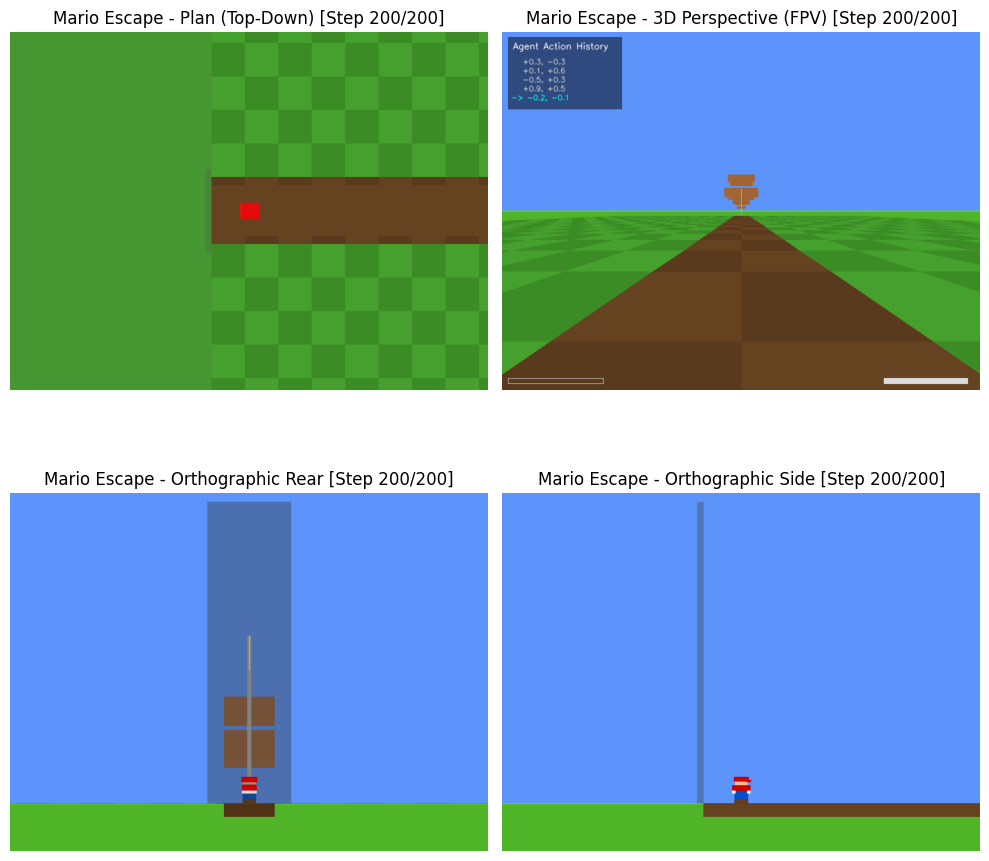

Top-Down Shape: (600, 800, 3)
Rear Shape: (600, 800, 3)
Side Shape: (600, 800, 3)
Perspective FPV Shape: (600, 800, 3)
Saving list of frames to Mario_Escape_grid.gif...
GIF saved successfully!


In [3]:
from game_envs.wrecking_ball_orthographic import WreckingBallEnv, WreckingBallOrthographicWrapper
from game_envs.toxic_gas_escape_orthographic import ToxicGasEscapeEnv, ToxicGasEscapeOrthographicWrapper
from game_envs.drone_dogfight_orthographic import DroneDogfightEnv, DroneDogfightOrthographicWrapper
from game_envs.excavator_orthographic import ExcavatorEnv, ExcavatorOrthographicWrapper
from game_envs.mario_orthographic import MarioEscapeEnv, MarioOrthographicWrapper

from gym.envs.box2d.lunar_lander import LunarLander
from game_envs.lunar_orthographic import LunarOrthographicWrapper

from gym.envs.box2d.bipedal_walker import BipedalWalker
from game_envs.bipedal_orthographic import BipedalOrthographicWrapper
from collections import deque

print("Testing All Envs...")

if __name__ == "__main__":
    env_factories = [
        ("Lunar Lander", lambda: LunarOrthographicWrapper(LunarLander())),
        ("Bipedal Walker", lambda: BipedalOrthographicWrapper(BipedalWalker())),
        ("Wrecking Ball", lambda: WreckingBallOrthographicWrapper(WreckingBallEnv())),
        ("Excavator", lambda: ExcavatorOrthographicWrapper(ExcavatorEnv())),
        #("Toxic Gas Escape", lambda: ToxicGasEscapeOrthographicWrapper(ToxicGasEscapeEnv())),
        ("Drone Dogfight", lambda: DroneDogfightOrthographicWrapper(DroneDogfightEnv())),
        ("Mario Escape", lambda: MarioOrthographicWrapper(MarioEscapeEnv())),
    ]
    num_steps = 200
    action_history = deque(maxlen=5)
    
    for name, make_env in env_factories:
        print(f"\n==========================================")
        print(f"Testing {name} Environment")
        print(f"==========================================")
        
        env = make_env()
        obs, info = env.reset()
        
        gif_list = []
        for step_idx in range(num_steps):
            # Sample an action matching the environment's action space shape
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            
            im_top_down, im_rear, im_side, im_fpv = env.render()
            
            fpv_hud = im_fpv.copy()
    
            action_history.append(action)

            # Draw a semi-transparent dark background box in the top-left corner
            overlay = fpv_hud.copy()
            cv2.rectangle(overlay, (10, 10), (200, 130), (0, 0, 0), -1)
            fpv_hud = cv2.addWeighted(overlay, 0.5, fpv_hud, 0.5, 0)

            cv2.putText(fpv_hud, "Agent Action History", (18, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

            # Render the past actions and the current action (newest at the bottom)
            for i, act in enumerate(action_history):
                is_current = (i == len(action_history) - 1)
                text_color = (0, 255, 255) if is_current else (200, 200, 200) # Cyan for current, grey for history
                prefix = "-> " if is_current else "   "

                # Format action values nicely (handles scalar or vector action spaces)
                act_str = f"{prefix}" + ", ".join([f"{val:+.1f}" for val in np.atleast_1d(act)])

                y_pos = 55 + (i * 15)
                cv2.putText(fpv_hud, act_str, (15, y_pos), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, text_color, 1, cv2.LINE_AA)
            
            clear_output(wait=True)
            # Plot the 2x2 Grid
            fig, axes = plt.subplots(2, 2, figsize=(10, 10))
            axes[0, 0].imshow(im_top_down)
            axes[0, 0].set_title(f"{name} - Plan (Top-Down) [Step {step_idx+1}/{num_steps}]")
            axes[0, 0].axis('off')
            axes[0, 1].imshow(fpv_hud)
            axes[0, 1].set_title(f"{name} - 3D Perspective (FPV) [Step {step_idx+1}/{num_steps}]")
            axes[0, 1].axis('off')
            axes[1, 0].imshow(im_rear)
            axes[1, 0].set_title(f"{name} - Orthographic Rear [Step {step_idx+1}/{num_steps}]")
            axes[1, 0].axis('off')
            axes[1, 1].imshow(im_side)
            axes[1, 1].set_title(f"{name} - Orthographic Side [Step {step_idx+1}/{num_steps}]")
            axes[1, 1].axis('off')
            plt.tight_layout()
            plt.show()
            
            # Force canvas draw to capture the figure as a high-fidelity image
            fig.canvas.draw()

            # Extract the RGBA buffer from the figure canvas and convert to a PIL Image
            rgba_image = Image.frombytes(
                "RGBA", fig.canvas.get_width_height(), fig.canvas.buffer_rgba()
            )
            gif_list.append(rgba_image.convert("RGB"))
    
            if terminated or truncated:
                break
        print(f"Top-Down Shape: {im_top_down.shape}")
        print(f"Rear Shape: {im_rear.shape}")
        print(f"Side Shape: {im_side.shape}")
        print(f"Perspective FPV Shape: {im_fpv.shape}")
        env.close()
        
        time.sleep(2)
        
        gif_path = f"{name.replace(' ', '_')}_grid.gif"
        print(f"Saving list of frames to {gif_path}...")

        gif_list[0].save(
            gif_path,
            save_all=True,
            append_images=gif_list[1:],
            duration=50,  # Duration between frames in milliseconds (e.g., 50ms = 20fps)
            loop=0,  # 0 = infinite loop
        )

        print("GIF saved successfully!")

In [4]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
from IPython.display import Audio, display
import io
import wave

class RetroAudioGenerator:
    def __init__(self, sample_rate=44100):
        self.sample_rate = sample_rate
        self.audio_enabled = True
        
        # Try to initialize the mixer normally
        try:
            pygame.mixer.init(frequency=self.sample_rate, size=-16, channels=2, buffer=512)
        except pygame.error as e:
            print(f"Standard audio init failed: {e}")
            print("Attempting to use dummy audio driver...")
            
            # If standard init fails (common in headless Linux/WSL), force the dummy driver
            os.environ["SDL_AUDIODRIVER"] = "dummy"
            try:
                pygame.mixer.init(frequency=self.sample_rate, size=-16, channels=2, buffer=512)
                print("Dummy audio driver loaded successfully. Audio will generate but not be heard.")
            except pygame.error as e2:
                print(f"Complete audio failure: {e2}")
                self.audio_enabled = False

    def _create_sound_object(self, wave_array, volume=0.5):
        """Converts a 1D numpy float array (-1.0 to 1.0) into a playable Pygame Sound."""
        class PlayableSound:
            def __init__(self, wave_data, sample_rate, pg_sound=None):
                self.wave_data = wave_data
                self.sample_rate = sample_rate
                self.pg_sound = pg_sound

            def play(self, *args, **kwargs): 
                # 1. Try to play via HTML5 Audio widget in Jupyter Notebooks
                played_in_jupyter = False
                try:
                    import IPython
                    from IPython.display import display, Audio
                    if get_ipython().__class__.__name__ == 'ZMQInteractiveShell':
                        # If a loop is requested, tile the array so it plays longer
                        play_data = self.wave_data
                        if kwargs.get('loops') == -1 or (len(args) > 0 and args[0] == -1):
                            play_data = np.tile(self.wave_data, 16) # Play the loop 16 times
                            
                        # Use IPython's native array support instead of raw WAV bytes
                        display(Audio(data=play_data, rate=self.sample_rate, autoplay=True))
                        played_in_jupyter = True
                        return
                except (ImportError, NameError, AttributeError):
                    pass # Not in Jupyter
                
                # 2. Fallback to standard Pygame playback (if hardware exists)
                if self.pg_sound and not played_in_jupyter:
                    try:
                        self.pg_sound.play(*args, **kwargs)
                    except Exception:
                        pass

        wave_array = np.clip(wave_array * volume, -1.0, 1.0)
        pg_sound = None
            
        if self.audio_enabled:
            try:
                # Apply volume and scale to 16-bit integer maximums
                sound_array = (wave_array * 32767).astype(np.int16)
                
                # Create stereo array
                stereo_array = np.column_stack((sound_array, sound_array))
                
                # Attempt to compile the sound
                pg_sound = pygame.sndarray.make_sound(stereo_array)
            except Exception as e:
                # If the dummy driver or sndarray module rejects the array, fail gracefully
                print(f"Sound compilation skipped: {e}")

        return PlayableSound(wave_array, self.sample_rate, pg_sound)

    def generate_laser(self, duration=0.15, start_freq=880, end_freq=220, volume=0.3):
        """Generates a classic 'pew' laser sound using a fast downward pitch sweep."""
        samples = int(self.sample_rate * duration)
        t = np.linspace(0, duration, samples, endpoint=False)
        
        # Exponential frequency drop
        freqs = np.linspace(start_freq, end_freq, samples)
        phase = np.cumsum(freqs) / self.sample_rate
        
        wave_array = np.sign(np.sin(2 * np.pi * phase))
        
        # Fast attack, fast decay envelope
        envelope = np.exp(-15 * t)
        wave_array *= envelope
        
        return self._create_sound_object(wave_array, volume)

    def generate_explosion(self, duration=0.4, volume=0.4):
        """Generates a crash/explosion sound using decaying white noise."""
        samples = int(self.sample_rate * duration)
        t = np.linspace(0, duration, samples, endpoint=False)
        
        # Generate pure white noise (-1.0 to 1.0)
        noise = np.random.uniform(-1.0, 1.0, samples)
        
        # 1. The "Punch": A low-frequency wave that drops in pitch rapidly
        freq_sweep = np.linspace(120, 20, samples) 
        phase = np.cumsum(freq_sweep) / self.sample_rate
        
        # Overdrive it into a square-like wave for retro crunch
        punch = np.sign(np.sin(2 * np.pi * phase)) * 0.5
        wave_array = noise * punch
        
        return self._create_sound_object(wave_array, volume)

    def generate_thrust(self, duration=0.1, volume=0.2):
        """Generates a low, rumbling engine thrust suitable for Lunar Lander."""
        samples = int(self.sample_rate * duration)
        
        # Low frequency noise (by smoothing white noise)
        noise = np.random.uniform(-1.0, 1.0, samples)
        smoothed_noise = np.convolve(noise, np.ones(20)/20, mode='same')
        
        # Add a subtle low-frequency hum
        t = np.linspace(0, duration, samples, endpoint=False)
        hum = np.sin(2 * np.pi * 40 * t) * 0.5
        
        wave_array = np.clip(smoothed_noise + hum, -1.0, 1.0)
        
        return self._create_sound_object(wave_array, volume)

    def generate_bgm_loop(self, bpm=150, volume=0.15):
        """Generates a seamless, repeating 8-bit arpeggio music loop."""
        # Retro minor arpeggio frequencies (C4, Eb4, G4, C5, G4, Eb4)
        notes = [261.63, 311.13, 392.00, 523.25, 392.00, 311.13]
        
        # Calculate duration of a single 16th note based on BPM
        note_duration = (60.0 / bpm) / 2
        
        # Generate the waveform for the entire sequence
        t_total = np.linspace(0, note_duration * len(notes), int(self.sample_rate * note_duration * len(notes)), endpoint=False)
        wave = np.zeros_like(t_total)
        
        for i, freq in enumerate(notes):
            start_idx = int(i * note_duration * self.sample_rate)
            end_idx = int((i + 1) * note_duration * self.sample_rate)
            
            # Local time array for this specific note
            t_note = t_total[start_idx:end_idx] - t_total[start_idx]
            
            # Generate a slightly softer square wave (duty cycle manipulation)
            sine = np.sin(2 * np.pi * freq * t_note)
            square = np.sign(sine + 0.3) # Adding a DC offset changes the pulse width
            
            # Apply a tight staccato envelope
            envelope = np.exp(-12 * t_note)
            
            wave[start_idx:end_idx] = square * envelope
            
        return self._create_sound_object(wave, volume)

    
audio_generator = RetroAudioGenerator()
bgm = audio_generator.generate_bgm_loop()
bgm.play(loops=-1)

In [ ]:
explosion = audio_generator.generate_explosion()
explosion.play()

In [ ]:
break

In [ ]:
from stable_baselines3 import PPO
from huggingface_sb3 import load_from_hub

np.bool8 = np.bool_

# ===============================================================
# 1. DOWNLOAD WEIGHTS & DEFINE AGENT CLASS
# ===============================================================
print("Downloading solved PPO weights from Hugging Face...")
checkpoint = load_from_hub(
    repo_id="sb3/ppo-LunarLander-v2",
    filename="ppo-LunarLander-v2.zip"
)
agent = PPO.load(checkpoint)

# ==========================================
# 2. ENVIRONMENT SETUP
# ==========================================
# Use the correct wrapper name we defined earlier
base_env = gym.make("LunarLander-v2", render_mode="rgb_array")
env = LunarOrthographicWrapper(base_env)

# ==========================================
# 3. INITIALIZATION & DATA EXTRACTION
# ==========================================
obs, info = env.reset()

print("Skipping intro animation...")
# 0 is the discrete action for "Do Nothing" (engines off)
for _ in range(10):
    obs, _, _, _, _ = env.step(0)

# Extract helipad coordinates for the minimap
helipad_x = (env.unwrapped.helipad_x1 + env.unwrapped.helipad_x2) / 2
helipad_y = env.unwrapped.helipad_y

# ==========================================
# 4. LET THE AI FLY
# ==========================================
total_reward = 0.0
print("Letting the AI control the Lander...")

# State variable names for the telemetry chart
state_labels = ["X", "Y", "vX", "vY", "Angle", "vAngle", "LegL", "LegR"]

for step in range(1000):
    
    # Predict discrete action [0, 1, 2, 3]
    action, _ = agent.predict(obs, deterministic=True)
    
    # Step the physics engine (extracting the scalar value)
    obs, reward, terminated, truncated, info = env.step(int(action.item()))
    
    # --- RENDERING ---
    im_top, im_rear, im_side, im_fpv = env.render()
    
    lander_x = env.unwrapped.lander.position.x
    lander_y = env.unwrapped.lander.position.y
    lander_angle = env.unwrapped.lander.angle
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    # [Row 0, Col 0] - Top-Down Camera
    axes[0, 0].imshow(im_top)
    axes[0, 0].set_title(f"Plan (Top-Down) - Step {step}")
    axes[0, 0].axis('off')

    # [Row 0, Col 1] - True 3D FPV
    axes[0, 1].imshow(im_fpv)
    axes[0, 1].set_title("3D Perspective (FPV)")
    axes[0, 1].axis('off')

    # [Row 0, Col 2] - Minimap
    axes[0, 2].set_title("2D Trajectory (Minimap)")
    axes[0, 2].set_xlim(0, 20)
    axes[0, 2].set_ylim(0, 20)
    
    # Draw helipad and lander
    axes[0, 2].scatter(helipad_x, helipad_y, color='gold', marker='s', s=800, label="Helipad")
    axes[0, 2].scatter(lander_x, lander_y, color='red', s=150, zorder=5, label='Lander')
    
    # Draw direction arrow
    axes[0, 2].arrow(lander_x, lander_y, -np.sin(lander_angle)*2, np.cos(lander_angle)*2, 
                     color='red', width=0.1, zorder=5)
    
    action_map = {0: "Coasting", 1: "Left Thruster", 2: "Main Engine", 3: "Right Thruster"}
    axes[0, 2].text(10, 18, f"Action: {action_map[int(action.item())]}", 
                    fontsize=14, ha='center', bbox=dict(facecolor='white', alpha=0.8))
    axes[0, 2].legend(loc="upper right")

    # [Row 1, Col 0] - Ortho Rear
    axes[1, 0].imshow(im_rear)
    axes[1, 0].set_title("Orthographic Rear")
    axes[1, 0].axis('off')

    # [Row 1, Col 1] - Ortho Side
    axes[1, 1].imshow(im_side)
    axes[1, 1].set_title("Orthographic Side")
    axes[1, 1].axis('off')

    # [Row 1, Col 2] - Live Telemetry
    axes[1, 2].bar(state_labels, obs, color='teal')
    axes[1, 2].set_title("Agent 1D Observation Vector (Telemetry)")
    axes[1, 2].set_ylim(-2.5, 2.5) # Standard normalized range for LunarLander states
    axes[1, 2].grid(axis='y', linestyle='--', alpha=0.7)
        
    if terminated or truncated:
        print(f"Episode finished! Total Score: {total_reward:.2f}")
        break
        
    display(fig)
    total_reward += reward
    clear_output(wait=True)
    plt.close(fig)

print(f"Final Reward: {total_reward}")
env.close()